In [1]:
import numpy as np
from tensorflow.keras.models import load_model
import joblib

2025-03-21 15:31:15.098646: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 15:31:15.283495: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-21 15:31:18.950510: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from tensorflow.keras.utils import to_categorical

In [3]:
import sys
sys.path.append('../data_preprocessing')

In [4]:
import feature_engineering_scaling as fes

In [5]:
# Load the saved models
model = joblib.load("../models/model_decision_tree_whole.pkl")

In [6]:
df = fes.X_scaled

In [7]:
X = df[['energy', 'r', 'z', 'phi', 'time']].iloc[1:].reset_index(drop=True)
y = fes.y[1:].reset_index(drop=True)

In [8]:
scaler = MinMaxScaler()
X.loc[:, 'time'] = scaler.fit_transform(X[['time']])  # Normalize safely

In [9]:
# Further split using train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Step 3: Predict probabilities on the unseen data
y_prob = model.predict_proba(X_test) 

In [11]:
y_pred = np.argmax(y_prob, axis=1)

In [12]:
np.unique(y_pred)

array([0, 1, 2, 3, 4, 5])

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

In [14]:
# Step 7: Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [15]:
np.unique(y_test)

array([0., 1., 2., 3., 4., 5.])

In [16]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.74      0.83    215765
         1.0       0.56      0.37      0.45    216281
         2.0       0.82      0.92      0.87    216781
         3.0       0.67      0.75      0.71    215864
         4.0       0.49      0.57      0.53    212120
         5.0       0.80      0.91      0.85    211796

    accuracy                           0.71   1288607
   macro avg       0.71      0.71      0.71   1288607
weighted avg       0.71      0.71      0.71   1288607



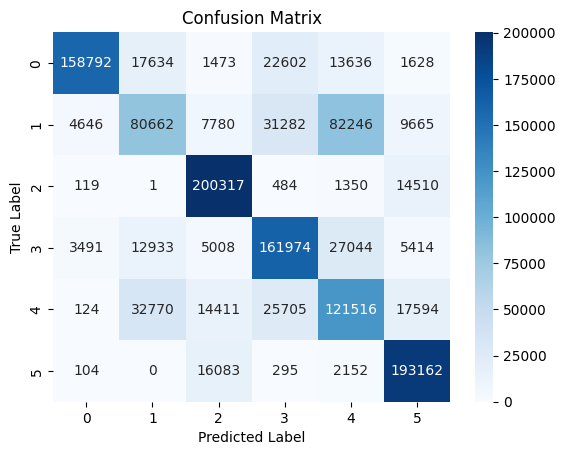

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# Step 9: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# Min-Max Unscaling Function
def minmax_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the min and max values derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after MinMaxScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    min_vals = X_unscaled[columns].min()
    max_vals = X_unscaled[columns].max()
    
    # Formula for unscaling using MinMax: 
    # unscaled_value = scaled_value * (max - min) + min
    X_scaled[columns] = X_scaled[columns] * (max_vals - min_vals) + min_vals
    
    return X_scaled

In [19]:
# Robust Unscaling Function
def robust_unscaler(X_unscaled, X_scaled, columns):
    """
    Unscale X_test using the median and IQR derived from the original X data.
    
    Parameters:
    - X_unscaled: Original (unscaled) data.
    - X_scaled: Scaled data (after RobustScaler).
    - columns: List of columns to be unscaled.
    
    Returns:
    - X_scaled: DataFrame with columns unscaled.
    """
    median_vals = X_unscaled[columns].median()
    iqr_vals = X_unscaled[columns].quantile(0.75) - X_unscaled[columns].quantile(0.25)
    
    # Formula for unscaling using RobustScaler:
    # unscaled_value = scaled_value * IQR + median
    X_scaled[columns] = X_scaled[columns] * iqr_vals + median_vals
    
    return X_scaled

In [20]:
# For MinMaxScaler unscaling
columns_minmax = ['energy', 'r', 'time']  # Columns you scaled with MinMaxScaler
X_test_unscaled_minmax = minmax_unscaler(fes.X, X_test.copy(), columns_minmax)


In [21]:

# For RobustScaler unscaling
columns_robust = ['z']  # Columns you scaled with RobustScaler
X_test_unscaled_robust = robust_unscaler(fes.X, X_test.copy(), columns_robust)


In [22]:
X_test.describe()

,energy,r,z,phi,time
count,1.288607e+06,1.288607e+06,1.288607e+06,1.288607e+06,1.288607e+06
mean,1.864425e-01,5.598997e-01,-1.849401e-05,6.620770e-04,6.663522e-01
std,1.955873e-01,1.943160e-01,5.731598e-01,1.812696e+00,2.361036e-01
min,1.141333e-06,4.846930e-04,-1.127277e+00,-3.141590e+00,0.000000e+00
25%,7.748819e-02,4.238794e-01,-5.000161e-01,-1.568017e+00,5.496703e-01
50%,9.997679e-02,5.987791e-01,1.557679e-04,4.554129e-04,6.997685e-01
75%,2.151500e-01,7.237751e-01,5.001147e-01,1.570935e+00,8.501954e-01
max,9.999890e-01,9.563552e-01,1.144904e+00,3.141593e+00,9.999998e-01


In [23]:
X_test.head()

,energy,r,z,phi,time
4435332,0.027271,0.172353,0.219464,1.229486,0.812891
4509608,0.070287,0.386756,-0.471225,-0.285059,0.819802
3894595,0.076211,0.589798,-0.594364,1.896670,0.762485
985345,0.718544,0.254429,-0.807264,-3.118813,0.456731
4123413,0.216862,0.709014,0.411318,1.602825,0.783824


In [24]:
X_test_unscaled_robust

,energy,r,z,phi,time
4435332,0.027271,0.172353,346.432230,1.229486,0.812891
4509608,0.070287,0.386756,-741.792384,-0.285059,0.819802
3894595,0.076211,0.589798,-935.805931,1.896670,0.762485
985345,0.718544,0.254429,-1271.244611,-3.118813,0.456731
4123413,0.216862,0.709014,648.710129,1.602825,0.783824
...,...,...,...,...,...
2338704,0.133111,0.714270,-773.578659,-1.946527,0.617200
525287,0.045380,0.693164,-222.533943,2.174897,0.243031
3741857,0.094209,0.428975,1129.744475,-0.590959,0.748244
2906993,0.668454,0.705595,-787.907793,-1.698450,0.670262


In [25]:
# Reset the index of each DataFrame
X_test_unscaled_minmax = X_test_unscaled_minmax.reset_index(drop=True)
X_test_unscaled_robust = X_test_unscaled_robust.reset_index(drop=True)
X_test= X_test.reset_index(drop=True)

# Now concatenate the DataFrames with 'phi' between 'z' and 'time'
combined_df = pd.concat([
    X_test_unscaled_minmax[['energy', 'r']],  # Columns from MinMax unscaled data
    X_test_unscaled_robust[['z']],  # 'z' from Robust unscaled data
    X_test[['phi']],  # Insert 'phi' here
    X_test_unscaled_robust[['time']]  # 'time' from Robust unscaled data
], axis=1)

In [26]:
combined_df.head()

,energy,r,z,phi,time
0,0.278065,321.765050,346.432230,1.229486,0.812891
1,0.716675,721.966594,-741.792384,-0.285059,0.819802
2,0.777074,1100.961950,-935.805931,1.896670,0.762485
3,7.326568,474.966122,-1271.244611,-3.118813,0.456731
4,2.211216,1323.489201,648.710129,1.602825,0.783824


In [27]:
from collections import Counter

def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.
    3) Breakdown of misclassified predictions for each class.
    4) Total number of events classified as the given class.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)

        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        # Misclassification breakdown: Find what other classes were mistaken as this class
        misclassified_counts = Counter(test_classes[pred_classes == cls])
        if cls in misclassified_counts:
            del misclassified_counts[cls]  # Remove true positives from misclassification count

        # Convert misclassification counts to percentages
        misclassification_percentages = {other_cls: (count / total_predicted_signal * 100) 
                                         for other_cls, count in misclassified_counts.items()}

        # Store results
        results[cls] = {
            "Total events classified as this class": total_predicted_signal,
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy,
            "Misclassification breakdown (%)": misclassification_percentages
        }

    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Total events classified as this class: {metrics['Total events classified as this class']}")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

        if metrics["Misclassification breakdown (%)"]:
            print(f"  - Misclassified as other classes:")
            for mis_cls, mis_perc in metrics["Misclassification breakdown (%)"].items():
                print(f"    - Class {mis_cls}: {mis_perc:.2f}%")

    return results

In [28]:
signal_detection_metrics(y_test, y_pred, [1,2,4,5])


Results for class 1:
  - Total events classified as this class: 144000
  - Percentage of actual signal events detected: 37.30%
  - Percentage of detected signal accuracy: 56.02%
  - Misclassified as other classes:
    - Class 4.0: 22.76%
    - Class 0.0: 12.25%
    - Class 3.0: 8.98%
    - Class 2.0: 0.00%

Results for class 2:
  - Total events classified as this class: 245072
  - Percentage of actual signal events detected: 92.41%
  - Percentage of detected signal accuracy: 81.74%
  - Misclassified as other classes:
    - Class 4.0: 5.88%
    - Class 3.0: 2.04%
    - Class 5.0: 6.56%
    - Class 1.0: 3.17%
    - Class 0.0: 0.60%

Results for class 4:
  - Total events classified as this class: 247944
  - Percentage of actual signal events detected: 57.29%
  - Percentage of detected signal accuracy: 49.01%
  - Misclassified as other classes:
    - Class 0.0: 5.50%
    - Class 1.0: 33.17%
    - Class 3.0: 10.91%
    - Class 5.0: 0.87%
    - Class 2.0: 0.54%

Results for class 5:
  - Tot

{1: {'Total events classified as this class': 144000,
  'Percentage of actual signal events detected': 37.29500048547954,
  'Percentage of detected signal accuracy': 56.01527777777778,
  'Misclassification breakdown (%)': {4.0: 22.756944444444443,
   0.0: 12.245833333333334,
   3.0: 8.981250000000001,
   2.0: 0.0006944444444444445}},
 2: {'Total events classified as this class': 245072,
  'Percentage of actual signal events detected': 92.40523846647078,
  'Percentage of detected signal accuracy': 81.73801984722857,
  'Misclassification breakdown (%)': {4.0: 5.880312724423843,
   3.0: 2.043481099432004,
   5.0: 6.562561206502579,
   1.0: 3.1745772670888557,
   0.0: 0.6010478553241496}},
 4: {'Total events classified as this class': 247944,
  'Percentage of actual signal events detected': 57.28644163680935,
  'Percentage of detected signal accuracy': 49.00945374762043,
  'Misclassification breakdown (%)': {0.0: 5.499628948472235,
   1.0: 33.17119994837544,
   3.0: 10.907301648759397,
   

In [29]:
X_test.shape

(1288607, 5)

In [30]:
from sklearn.metrics import roc_curve, auc
import os

def plot_event_analysis(X_test, y_pred, model_name, save_dir, event_types=[1, 2, 4, 5], save_plots=False):
    """
    Plot energy distributions, decay curves, and ROC curve for a given model, and optionally save them.

    Parameters:
        X_test (pandas DataFrame): Feature dataset containing 'r', 'z', and 'time' columns.
        y_pred (numpy array): Predicted event labels (truths).
        model_name (str): Name of the model (used for plot titles and filenames).
        save_dir (str): Path to the directory where plots will be saved.
        event_types (list): List of event types to plot (default includes Bi214, Po214, Bi212, Po212).
        save_plots (bool): Whether to save the plots as PNG files (default is False).
    """
    event_labels = {1: "Bi214", 2: "Po214", 4: "Bi212", 5: "Po212"}

    # Create directory if it doesn't exist
    if save_plots and not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Energy Distribution Plots
    energy_values = X_test.iloc[:, 0]  # Assuming energy is the first column
    
    for event_type in event_types:
        if event_type not in event_labels:  # Skip if event type isn't in the dictionary
            continue
        label = event_labels[event_type]
        plt.figure(figsize=(10, 6))
        
        # Filter energy values for this event type
        event_energy = energy_values[y_pred == event_type]
        
        # Plot histogram
        plt.hist(event_energy, bins=200, alpha=0.7, color="blue", density=True)
        
        # Labels and title
        plt.xlabel("Energy (MeV)")
        plt.ylabel("Number of Events")
        plt.title(f"Energy Distribution of {label} - {model_name}")
        plt.grid(True)
        
        # Save the plot if required
        if save_plots:
            plt.savefig(f"{save_dir}{model_name}_energy_{label}.png")
        
        # Show each plot separately
        plt.show()
    
    # Decay Curve Calculation
    def calculate_time_differences(X_test, y_pred, parent, daughter):
        """
        Calculate time differences between parent and daughter decays.

        Parameters:
            X_test (pandas DataFrame): Feature dataset containing time as the last column.
            y_pred (numpy array): The predicted event labels.
            parent (int): The parent event type (e.g., Bi214).
            daughter (int): The daughter event type (e.g., Po214).
        
        Returns:
            np.array: Array of time differences.
        """
        time_values = X_test.iloc[:, -1].values  # Extract time column (last column)

        # Get times of parent and daughter events
        parent_times = time_values[y_pred == parent]
        daughter_times = time_values[y_pred == daughter]

        time_diffs = []
        for pt in parent_times:
            valid_daughters = daughter_times[daughter_times > pt]
            if len(valid_daughters) > 0:
                time_diffs.append(valid_daughters[0] - pt)  # Take the first valid decay

        return np.array(time_diffs)

    # Plot decay curves
    for parent, daughter in [(1, 2), (4, 5)]:
        if parent in event_types and daughter in event_types:
            time_diffs = calculate_time_differences(X_test, y_pred, parent, daughter)
            label = f"{event_labels[parent]} → {event_labels[daughter]}"
            plt.figure(figsize=(10, 6))
            plt.hist(time_diffs, bins=100, alpha=0.6, color="blue", density=True, label=label)
            plt.xlabel("Time Difference (s)")
            plt.ylabel("Number of events")
            plt.title(f"Decay Curve of {label} - {model_name}")
            plt.yscale("log")  # Log scale for better visualization
            plt.legend()
            plt.grid(True)
            
            # Save the plot if required
            if save_plots:
                plt.savefig(f"{save_dir}{model_name}_decay_curve_{label}.png")
            
            # Show each plot separately
            plt.show()
    
    # External Background (Class 3) Analysis (r and z)
    r_values = X_test["r"][y_pred == 3]
    z_values = X_test["z"][y_pred == 3]
    
    # Plot r histogram
    plt.figure(figsize=(10, 6))
    plt.hist(r_values, bins=100, alpha=0.6, color="blue", density=True)
    plt.xlabel("r (Radius)")
    plt.ylabel("Number of Events")
    plt.title(f"Histogram of r for External Background (Class 3) - {model_name}")
    plt.grid(True)
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_r_external_background.png")
    
    # Show the plot
    plt.show()

    # Plot z histogram
    plt.figure(figsize=(10, 6))
    plt.hist(z_values, bins=100, alpha=0.6, color="red", density=True)
    plt.xlabel("z (Height)")
    plt.ylabel("Number of Events")
    plt.title(f"Histogram of z for External Background - {model_name}")
    plt.grid(True)
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_z_external_background.png")
    
    # Show the plot
    plt.show()

    # Binary Classification and ROC curve
    binary_mapping = {
        0: 0,  # Map original class 0 to binary class 0
        1: 1,
        2: 1,
        3: 0,  # Map original class 3 to binary class 0
        4: 1,  # Map original class 4 to binary class 1
        5: 1,  # Map original class 5 to binary class 1
    }

    # Convert predictions and truth to binary
    binary_probs = np.array([binary_mapping[label] for label in y_pred])

    # Assuming y_test is available
    binary_truth = np.array([binary_mapping[x] for x in y_test])

    # Compute ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(binary_truth, binary_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve - {model_name}')
    plt.legend()
    plt.grid()
    
    # Save the plot if required
    if save_plots:
        plt.savefig(f"{save_dir}{model_name}_roc_curve.png")
    
    # Show the plot
    plt.show()

In [31]:
# Set the save directory before the function
save_dir = "../plots/decision_tree_whole/"

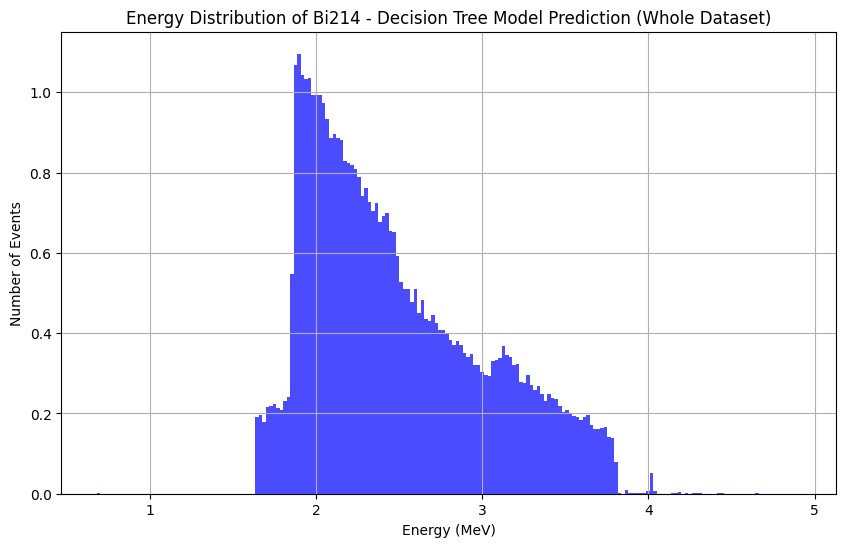

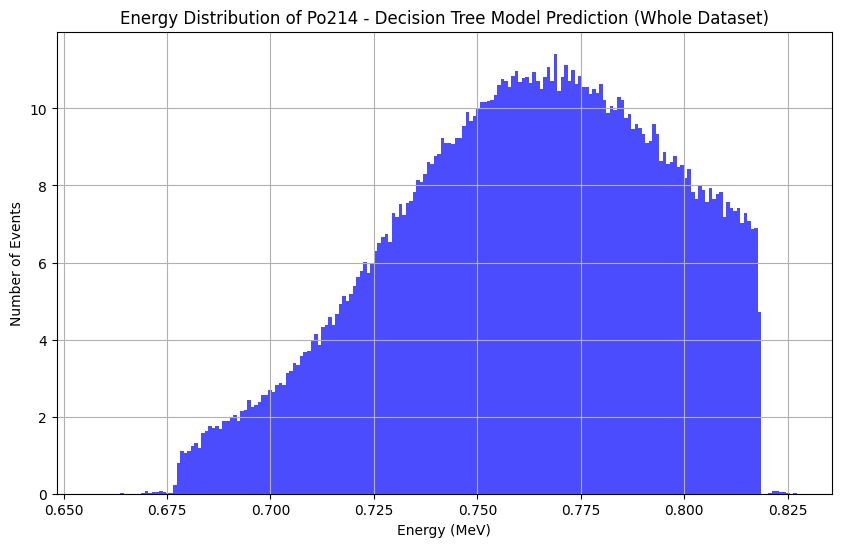

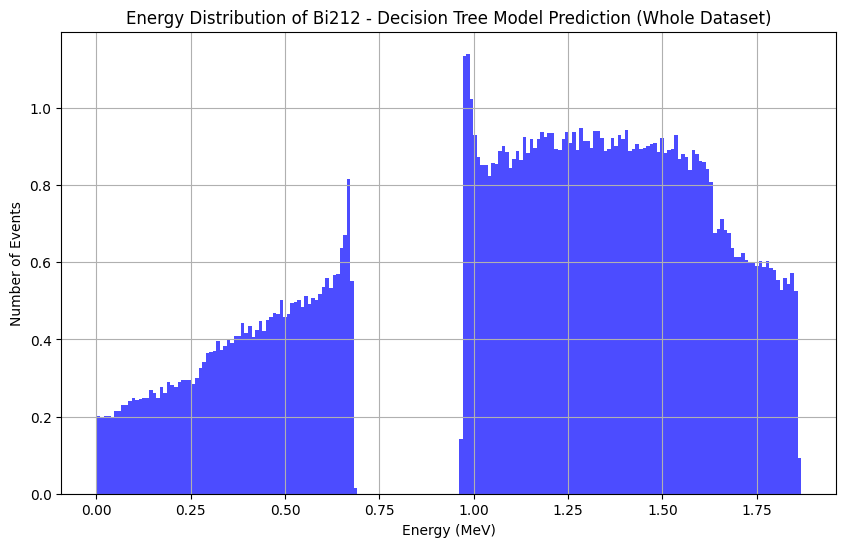

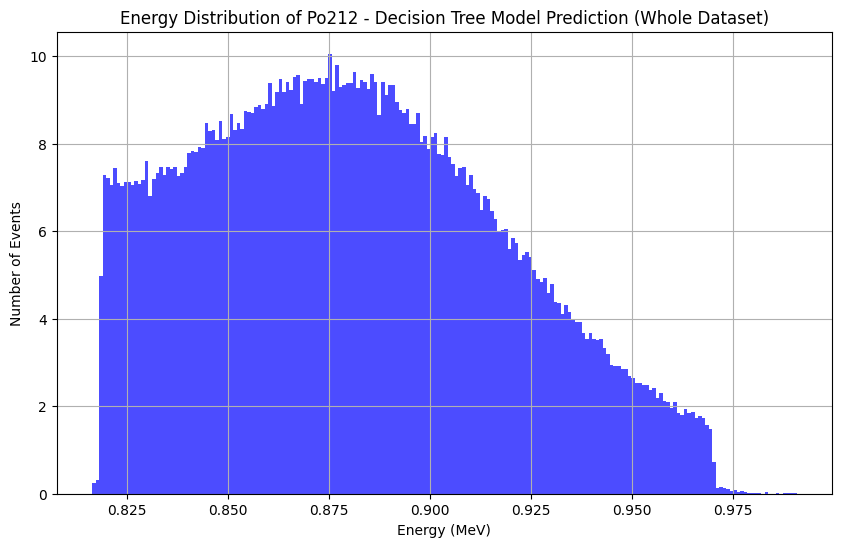

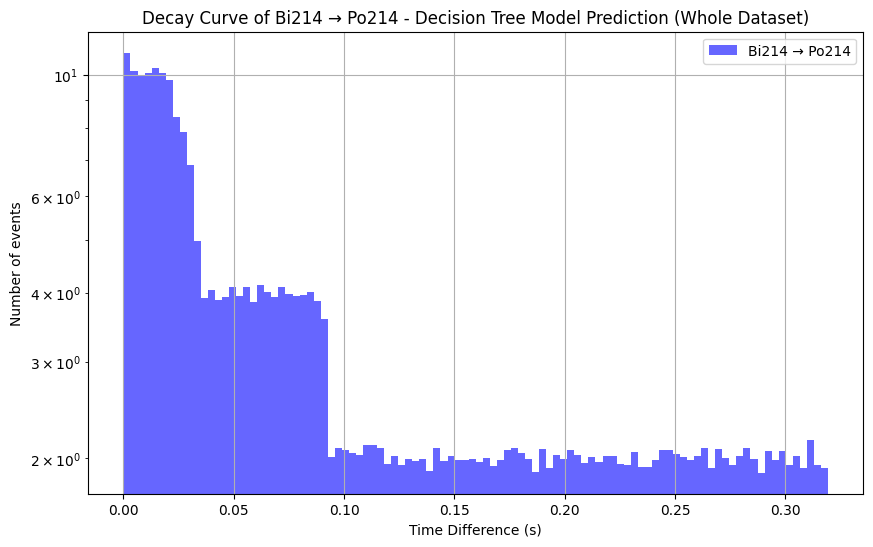

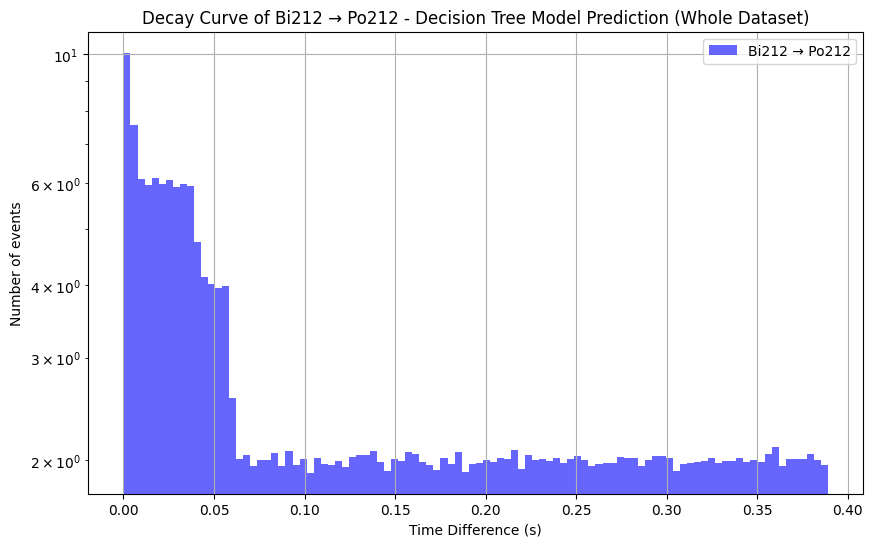

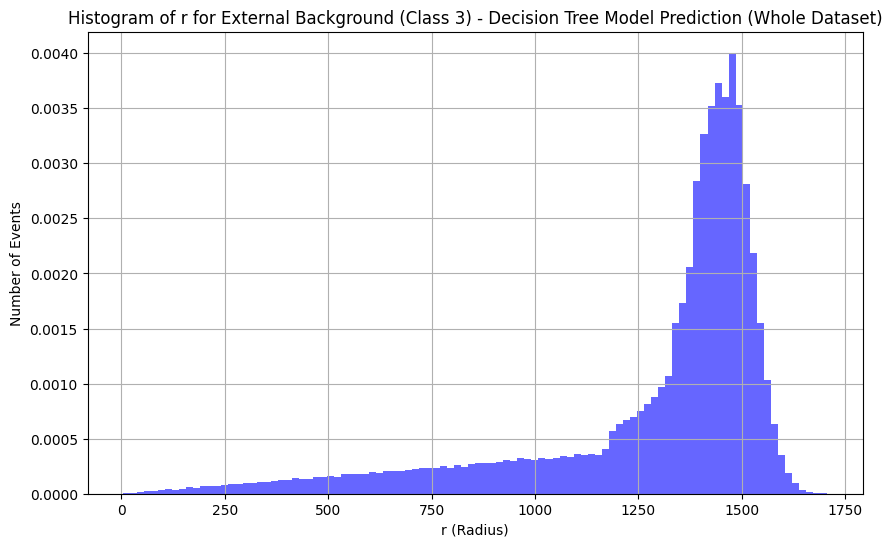

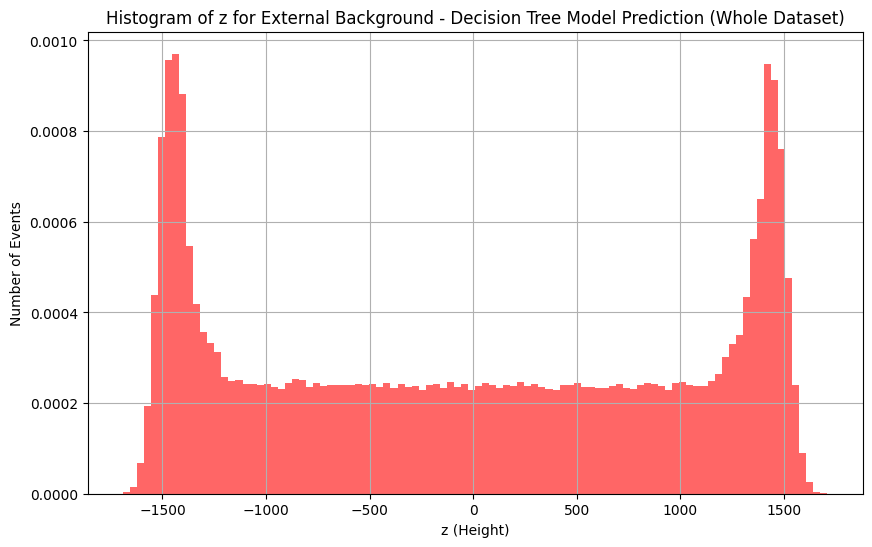

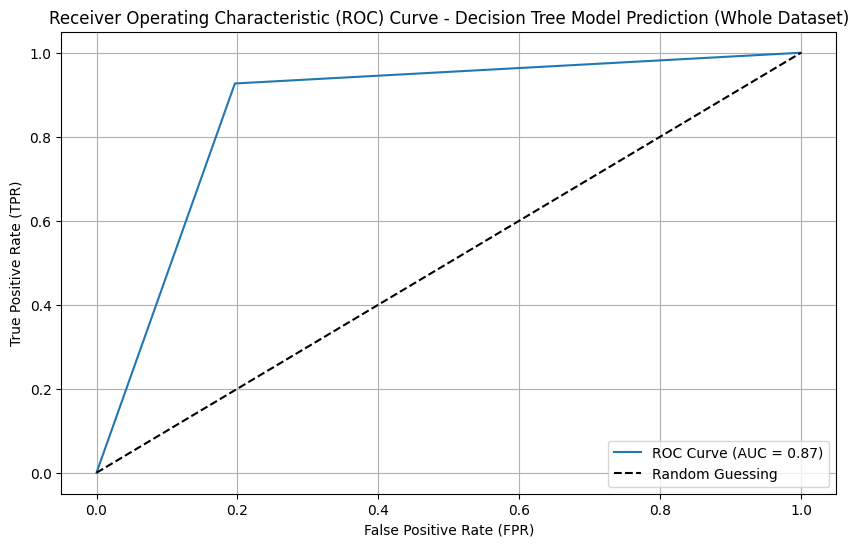

In [33]:
# Call the function and pass save_dir
plot_event_analysis(combined_df, y_pred, model_name="Decision Tree Model Prediction (Whole Dataset)", save_dir=save_dir, event_types=[1, 2, 4, 5], save_plots=True)